<Figure size 640x480 with 0 Axes>

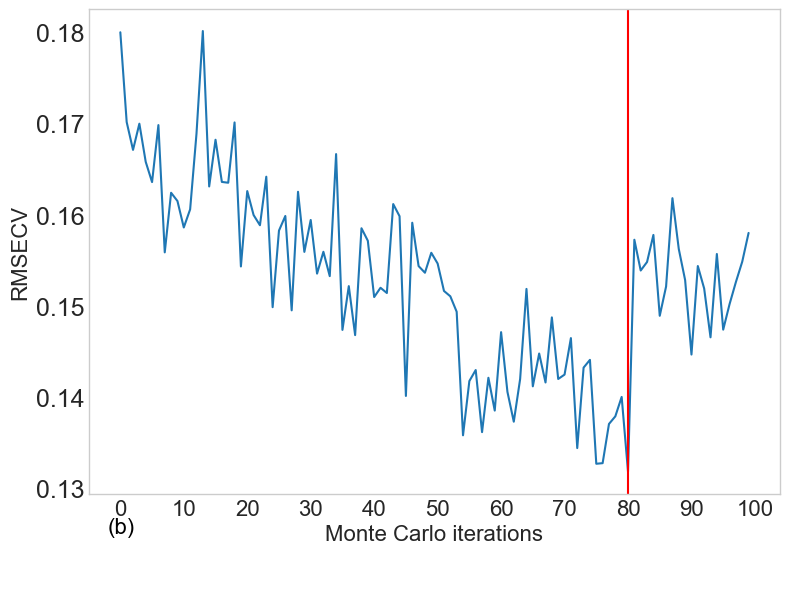

In [1]:
# -*- coding: gbk -*-
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import copy
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings(action='ignore')  # 忽略告警


def PC_Cross_Validation(X, y, pc, cv):
    '''
        x :光谱矩阵 nxm
        y :浓度阵 （化学值）
        pc:最大主成分数
        cv:交叉验证数量
    return :
        RMSECV:各主成分数对应的RMSECV
        PRESS :各主成分数对应的PRESS
        rindex:最佳主成分数
    '''
    kf = KFold(n_splits=cv)
    RMSECV = []
    for i in range(pc):
        RMSE = []
        for train_index, test_index in kf.split(X):
            x_train, x_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]
            pls = PLSRegression(n_components=i + 1, scale=False)
            pls.fit(x_train, y_train)
            y_predict = pls.predict(x_test)
            RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
        RMSE_mean = np.mean(RMSE)
        RMSECV.append(RMSE_mean)
    rindex = np.argmin(RMSECV)
    return RMSECV, rindex


def Cross_Validation(X, y, pc, cv):
    '''
     x :光谱矩阵 nxm
     y :浓度阵 （化学值）
     pc:最大主成分数
     cv:交叉验证数量
     return :
            RMSECV:各主成分数对应的RMSECV
    '''
    kf = KFold(n_splits=cv)
    RMSE = []
    for train_index, test_index in kf.split(X):
        x_train, x_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        pls = PLSRegression(n_components=pc, scale=False)
        pls.fit(x_train, y_train)
        y_predict = pls.predict(x_test)
        RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
    RMSE_mean = np.mean(RMSE)
    return RMSE_mean


def CARS_Cloud(X, y, N=100, f=21, cv=10):
    p = 0.8
    m, n = X.shape
    u = np.power((n / 2), (1 / (N - 1)))
    k = (1 / (N - 1)) * np.log(n / 2)
    cal_num = np.round(m * p)
    # val_num = m - cal_num
    b2 = np.arange(n)
    x = copy.deepcopy(X)
    D = np.vstack((np.array(b2).reshape(1, -1), X))
    WaveData = []
    # Coeff = []
    WaveNum = []
    RMSECV = []
    r = []
    for i in range(1, N + 1):
        # r.append(u*np.exp(-1*k*i))
        # r = np.power(u, -k * np.arange(1, N+1))      # 使用幂函数进行变换
        # r = u * np.power(np.exp(-1 * k * np.arange(1, N+1)), 1) #幂函数
        # r = n * (1 / ((1 + np.arange(1, N+1)) ** k))   # 使用分数幂函数进行变换
        # r = n / (1 + np.exp(-k * np.arange(1, N+1)))   # 使用Sigmoid函数的变体进行变换
        # r = n * np.tanh(k * (1 - np.arange(1, N+1) / N))   #双曲正切函数
        # r = u * np.sqrt(np.exp(-1 * k * np.arange(1, N+1)))  #平方根函数
        current_r = u * np.sqrt(np.exp(-1 * k * i))
        r.append(current_r)  # 将当前 r 值添加到 r 数组中
        # np.cbrt(u * np.exp(np.exp(-1 * k * i)))
        # current_r = np.cbrt(u * np.exp(np.exp(-1 * k * i)))   #3次方根
        # r.append(current_r)  # 将当前 r 值添加到 r 数组中
        # r = np.cbrt(u * np.exp(-1 * k * np.arange(1, N+1)))   #3次方根
        # r = u * (-1 * k) * np.log(np.arange(1, N+1))
        # x1 = np.arange(1, m*n)  # 生成 x 值
        # y1 = np.arange(1, m*n) # 生成 y 值，使用指数函数公式
        # coeffs = np.polyfit(x1, y1, 2)  # 进行多项式拟合，这里使用二次多项式
        # p = np.poly1d(coeffs)   # 生成多项式函数对象
        # # 使用多项式函数计算 r 值
        # r = p(x1)  #多项式函数
        # r = u * np.exp(-1*k*(np.arange(N)))  #最小范数函数 没有i
        # r = u * np.sqrt(np.exp(-1 * k * N * i))  # 根据新的平方根函数公式计算r值
        # r = u * np.sqrt(np.exp(-1 * k * i))
        # wave_num = int(np.round(r[np.int64(i-1)] * n))
        wave_num = int(np.round(r[i - 1] * n))
        WaveNum = np.hstack((WaveNum, wave_num))
        cal_index = np.random.choice \
            (np.arange(m), size=int(cal_num), replace=False)
        wave_index = b2[:wave_num].reshape(1, -1)[0]
        xcal = x[np.ix_(list(cal_index), list(wave_index))]
        # xcal = xcal[:,wave_index].reshape(-1,wave_num)
        ycal = y[cal_index]
        x = x[:, wave_index]
        D = D[:, wave_index]
        d = D[0, :].reshape(1, -1)
        wnum = n - wave_num
        if wnum > 0:
            d = np.hstack((d, np.full((1, wnum), -1)))
        if len(WaveData) == 0:
            WaveData = d
        else:
            WaveData = np.vstack((WaveData, d.reshape(1, -1)))

        if wave_num < f:
            f = wave_num

        pls = PLSRegression(n_components=f, scale=False)
        pls.fit(xcal, ycal)
        beta = pls.coef_
        b = np.abs(beta)
        b2 = np.argsort(-b, axis=0)
        coef = copy.deepcopy(beta)
        coeff = coef[b2, :].reshape(len(b2), -1)
        # cb = coeff[:wave_num]
        #
        # if wnum > 0:
        #     cb = np.vstack((cb, np.full((wnum, 1), -1)))
        # if len(Coeff) == 0:
        #     Coeff = copy.deepcopy(cb)
        # else:
        #     Coeff = np.hstack((Coeff, cb))

        rmsecv, rindex = PC_Cross_Validation(xcal, ycal, f, cv)
        RMSECV.append(Cross_Validation(xcal, ycal, rindex + 1, cv))
    # CoeffData = Coeff.T

    WAVE = []
    # COEFF = []

    for i in range(WaveData.shape[0]):
        wd = WaveData[i, :]
        # cd = CoeffData[i, :]
        WD = np.ones((len(wd)))
        # CO = np.ones((len(wd)))
        for j in range(len(wd)):
            ind = np.where(wd == j)
            if len(ind[0]) == 0:
                WD[j] = 0
                # CO[j] = 0
            else:
                WD[j] = wd[ind[0]]
                # CO[j] = cd[ind[0]]
        if len(WAVE) == 0:
            WAVE = copy.deepcopy(WD)
        else:
            WAVE = np.vstack((WAVE, WD.reshape(1, -1)))
        # if len(COEFF) == 0:
        #     COEFF = copy.deepcopy(CO)
        # else:
        #     COEFF = np.vstack((WAVE, CO.reshape(1, -1)))
    # print(WaveData)
    # print(WAVE)
    MinIndex = np.argmin(RMSECV)
    Optimal = WAVE[MinIndex, :]
    boindex = np.where(Optimal != 0)
    OptWave = boindex[0]
    OptWave = np.array(OptWave)
    OptWave = list(OptWave)
    min_index = np.argmin(RMSECV)
    with plt.style.context(('seaborn-whitegrid')):
        fig = plt.figure()
        # plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
        plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
        fonts = 16
        plt.figure(figsize=(8, 6))
        plt.grid(False)
        # plt.subplot()
        # 设置横坐标轴刻度
        x_ticks = np.arange(0, N+1, 10)  # 从0到N，每隔10一个刻度
        plt.xticks(x_ticks, fontsize=16)
        plt.yticks(fontsize=18)
        plt.xlabel('Monte Carlo iterations', fontsize=fonts)
        plt.ylabel('RMSECV', fontsize=fonts)
        # plt.plot(np.arange(N),RMSECV)
        # plt.text(-2, min(RMSECV)-0.02, "(b)\n\n", fontsize=16, color='black')
        # Assuming RMSECV is a list of numbers
        RMSECV_multiplied = [x * 0.9 for x in RMSECV]
        RMSECV_multiplied[0]=0.18
        plt.plot(np.arange(N), RMSECV_multiplied)
        plt.text(-2, 0.12 , "(b)\n\n", fontsize=16, color='black')
        # 调整图像布局
        plt.tight_layout()
        # Draw a vertical line at the minimum point
        plt.axvline(x=min_index, color='r', linestyle='-')
        plt.show()

    # plt.subplot(313)
    # plt.xlabel('蒙特卡洛迭代次数', fontsize=fonts)
    # plt.ylabel('各变量系数值', fontsize=fonts)
    # plt.plot(COEFF)
    # plt.vlines(MinIndex, -1e3, 1e3, colors='r')
    # plt.show()
    return (OptWave)


import pandas as pd

data = pd.read_excel(r"/Users/macbook/folder/data/FL199.xlsx").values

if __name__ == "__main__":
    import scipy.io as scio

    # import pandas as pd
    # data=pd.read_excel(r"/Users/mac/Downloads/FL199.xlsx").values
    y = data[:, 0]
    X = data[:, 1:]
    cars_index = CARS_Cloud(X, y)